This file contains my solution to a task from [Data Science Simulator](https://karpov.courses/simulator-ds), a hands-on training course in data analysis and machine learning by karpov.courses.

This file is shared with the permission of the course authors, and in a reduced form: the original problem statements and datasets are omitted. What's kept is my own code, reasoning, and commentary.

## Overview

In the ML: Smart Link 1 task I implemented an algorithm that picks offers based on the average revenue per click.

In this task I implement an A/B test that compares the effectiveness of randomly showing ads to a user against one of the algorithms from the Smart Link 1 task.

### Step 1

Splitting users into a control (A) and a test (B) group.
There are different approaches to splitting users. I implement the simplest one — random splitting.
There can be several experiments, and each one may require reshuffling the users anew.
The simplest way is to add a salt to the user identifier and then take the hash of this composite identifier. The salt is some text string, unique to each experiment. This produces a new "salted identifier" that is fed into the traffic-splitting algorithm. If the splitting algorithm works correctly, it will split identifiers with different salts differently.

The salt is a random string of a few characters.

#### Task
I need to implement a separate `Experiment` class with a single method `group`, which returns which group a click belongs to. The experiment parameters are set when the instance is created: `experiment_id`, `groups` (optional) and `group_weights` (optional).

The method must split clicks as evenly as possible, but proportionally to the group weight. It must not happen that the first clicks all go to group A and the later clicks to group B. At the same time, different experiments with a different salt must split clicks differently.

For experiments with the same `experiment_id` and the same parameters (groups and weights), the same `click_id` must always fall into the same group.

If weights are not set, the distribution between groups is assumed to be uniform.
If weights are set, they must sum to 1.

#### Implementation
So the algorithm correctly handles the possibility of unequal groups, I do the splitting as follows:
- compute the remainder of dividing the hash by some large value M
- compute the prefix sum over the weights and multiply each value by M

In this scenario both the hash remainder and the weights lie between 0 and M.
Then I look for which interval in the prefix sum the hash remainder falls into.
If, for example, the weights were [0.9, 0.05, 0.05] and M = 100, the intervals would be: [0, 90), [90, 95), [95, 100). If the hash remainder falls into [0, 90), that means I assign it to the first group.

In [1]:
import math
import hashlib
from typing import Tuple, List

class Experiment:
    """Experiment class. Contains the logic for assigning users to groups."""
    
    def __init__(
        self,
        experiment_id: int,
        groups: Tuple[str] = ("A", "B"),
        group_weights: List[float] = None,
    ):
        self.experiment_id = experiment_id
        self.groups = groups
        self.group_weights = group_weights
        
        self.salt = "expid:" + str(self.experiment_id)
        
        #Constant for hash and weights normalization
        self.M = 10**6
        
        #Define the groups sum and check whether the weights sum equals to 1
        if self.group_weights is not None:
            sum_weights = sum(self.group_weights)
            if not math.isclose(sum_weights, 1.0, abs_tol=0.001):
                raise ValueError(f"Weights sum={sum_weights} is not equal to 1")
        else:
            self.group_weights = [1/len(self.groups)]*len(self.groups)
            
    def group(self, click_id: int) -> Tuple[int, str]:
        """Assigns a click to a group.
        Parameters
        ----------
        click_id: int :
            id of the click

        Returns
        -------
        Tuple[int, str] :
            group id and group name
        """
        
        #Salt + hash
        salted_click = self.salt + "click:" + str(click_id)
        res_md5 = hashlib.md5(salted_click.encode())
        hashed_click = int(res_md5.hexdigest(), 16)
        
        #Calculate cumulative weights normalized by M
        hashed_norm = hashed_click % self.M
        s = [0]*(len(self.group_weights)+1)
        for i in range(1, len(self.group_weights)+1):
            s[i] = s[i-1] + self.group_weights[i-1]
        weights_cumulative = [self.M*w for w in s[1:]]
        
        #Determine what group the click belongs to
        for i, weight in enumerate(weights_cumulative):
            if hashed_norm <= weight:
                return i, self.groups[i]

### Step 2

Every ad impression has a certain probability of the user converting into the desired action — `CVR` (conversion rate). Each impression is modeled by a Bernoulli distribution. For a set of impressions this becomes a binomial distribution.
The reward for each action is `CPA` (cost-per-action). Within this task the reward is assumed to follow a normal distribution with parameters `reward_avg` (mean) and `reward_std` (standard deviation).

#### Task
I need to generate a sample of ad-impression results and compute an array of `CPC` values — cost-per-click, the reward for each conversion.
After that I run a t-test comparing two `CPC` arrays generated this way.

#### Interpreting the t-test results
The `ttest_ind` method from `scipy` returns a `p-value` — the probability of obtaining the returned statistic value. If the `p-value` is greater than the significance level `alpha`, then the probability of error when rejecting the null hypothesis (that the sample means are identical) is higher than what we allowed ourselves. In that case the H0 hypothesis stands. If the `p-value` is smaller than `alpha`, we reject H0.

In [3]:
import scipy
import numpy as np

def cpc_sample(
    n_samples: int,
    conversion_rate: float,
    reward_avg: float,
    reward_std: float
) -> np.ndarray:
    """Sample data."""
    
    cvr = scipy.stats.bernoulli.rvs(conversion_rate, size=n_samples)
    cpa = scipy.stats.norm.rvs(loc=reward_avg, scale=reward_std, size=n_samples)
    cpa[cpa < 0] = 0
    
    cpc = cvr*cpa
    return cpc

def t_test(cpc_a: np.ndarray, cpc_b: np.ndarray, alpha=0.05
) -> Tuple[bool, float]:
    """Perform t-test.

    Parameters
    ----------
    cpc_a: np.ndarray :
        first samples    
    cpc_b: np.ndarray :
        second samples
    alpha :
         (Default value = 0.05)

    Returns
    -------
    Tuple[bool, float] :
        True if difference is significant, False otherwise
        p-value
    """
    ttest_res = scipy.stats.ttest_ind(cpc_a, cpc_b)
    pvalue = ttest_res.pvalue
    if pvalue > alpha:
        return False, pvalue
    else:
        return True, pvalue

## Step 3

#### Task
I need to run A/A testing and estimate the share of type I errors when testing two deliberately identical samples. With a large number of tests the expected share of errors will be approximately equal to the significance level `alpha`.

In [4]:
def aa_test(
    n_simulations: int,
    n_samples: int,
    conversion_rate: float,
    reward_avg: float,
    reward_std: float,
    alpha: float = 0.05,
) -> float:
    """Do the A/A test (simulation)."""
    pvalues = np.zeros(n_simulations)
    type_1_errors = np.zeros(n_simulations)
    for i in range(n_simulations):
        cpc_1 = cpc_sample(n_samples, conversion_rate, reward_avg, reward_std)
        cpc_2 = cpc_sample(n_samples, conversion_rate, reward_avg, reward_std)
        result = t_test(cpc_1, cpc_2, alpha)
        pvalues[i] = result[1]

        if result[0]:
            type_1_errors[i] = 1

    #Calcuate type 1 errors rate
    type_1_errors_rate = sum(type_1_errors)/len(type_1_errors)

    return type_1_errors_rate, pvalues

(array([1039.,  982., 1019.,  987., 1014.,  977., 1034., 1014.,  992.,
         942.]),
 array([9.87191721e-05, 1.00072628e-01, 2.00046537e-01, 3.00020447e-01,
        3.99994356e-01, 4.99968265e-01, 5.99942174e-01, 6.99916083e-01,
        7.99889992e-01, 8.99863902e-01, 9.99837811e-01]),
 <BarContainer object of 10 artists>)

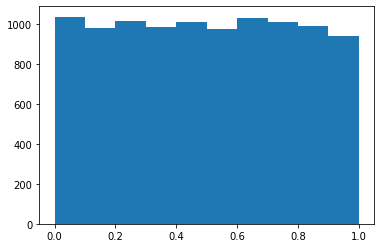

In [ ]:
plt.hist(pvalues)

The p-value distribution is uniform, which is the expected result given that the samples are generated by the same distribution. Accordingly, in the fraction of experiments corresponding to the significance level `alpha`, a type I error will occur.

## Step 4

#### Task

I need to run an A/B test with deliberately different samples (the `conversion_rate` should differ by `MDE` (minimal detectable effect)) and collect statistics on the occurrence of type II errors — failing to accept hypothesis H1 when it is correct. The probability of a type II error is denoted $\beta$, and the power of the test is defined as $1 - \beta$ — the probability of accepting H1 when it is correct.

In [5]:
def ab_test(
    n_simulations: int,
    n_samples: int,
    conversion_rate: float,
    mde: float,
    reward_avg: float,
    reward_std: float,
    alpha: float = 0.05,
) -> float:
    """Do the A/B test (simulation)."""

    conversion_h1 = conversion_rate * (1 + mde)
    type_2_errors = np.zeros(n_simulations)
    pvalue = np.zeros(n_simulations)
    for i in range(n_simulations):
        # Generate one cpc sample with the given conversion_rate, reward_avg, and reward_std
        # Generate another cpc sample with the given conversion_rate * (1 + mde), reward_avg, and reward_std
        # Check t-test and save type 2 error
        cpc_1 = cpc_sample(n_samples, conversion_rate, reward_avg, reward_std)
        cpc_2 = cpc_sample(n_samples, conversion_h1, reward_avg, reward_std)
        result = t_test(cpc_1, cpc_2, alpha)
        if result[0] is False:
            type_2_errors[i] = 1
        pvalue[i] = result[1]


    # Calculate the type 2 errors rate
    type_2_errors_rate = sum(type_2_errors)/len(type_2_errors)

    return type_2_errors_rate, pvalue

(array([463., 171.,  93.,  62.,  42.,  36.,  43.,  32.,  30.,  28.]),
 array([9.68134523e-06, 9.98986993e-02, 1.99787717e-01, 2.99676735e-01,
        3.99565753e-01, 4.99454771e-01, 5.99343789e-01, 6.99232807e-01,
        7.99121825e-01, 8.99010843e-01, 9.98899861e-01]),
 <BarContainer object of 10 artists>)

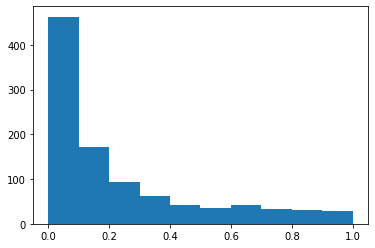

In [ ]:
import matplotlib.pyplot as plt
plt.hist(pvalue)

The distribution of `p-value` depends on how strong an effect we want to observe (what `MDE` value we specify).
It is not a uniform distribution, as it is in the case of samples generated by identical distributions.

In [ ]:
# Type 2 errors dependency on MDE
mdes = np.arange(0.05, 0.4, 0.05)
type_2_errors = np.zeros(len(mdes))

for i, mde in enumerate(mdes):
    type_2_errors_rate, pvalues = ab_test(
        n_simulations=1000,
        n_samples=10000,
        conversion_rate=0.05,
        mde=mde,
        reward_avg=50,
        reward_std=10,
        alpha=0.05
    )
    type_2_errors[i] = type_2_errors_rate

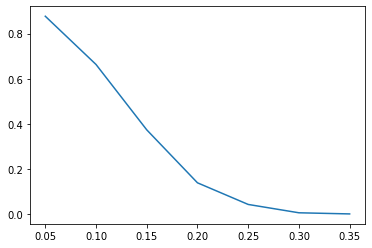

In [ ]:
plt.plot(mdes, type_2_errors)

As `MDE` grows, the frequency of type II errors falls.

## Step 5

I need to empirically find the optimal values of `n_samples` and `MDE` at which the frequencies of type I and type II errors do not exceed some level we are comfortable with.

In [6]:
from typing import List, Tuple
import numpy as np
from scipy import stats


def select_sample_size(
    n_samples_grid: List[int],
    n_simulations: int,
    conversion_rate: float,
    mde: float,
    reward_avg: float,
    reward_std: float,
    alpha: float = 0.05,
    beta: float = 0.2,
) -> Tuple[int, float, float]:
    """Select sample size."""
    for n_samples in n_samples_grid:
        type_1_error = aa_test(
            n_simulations=n_simulations,
            n_samples = n_samples,
            conversion_rate = conversion_rate,
            reward_avg = reward_avg,
            reward_std = reward_std,
            alpha = alpha
        )
        
        type_2_error = ab_test(
            n_simulations=n_simulations,
            n_samples = n_samples,
            conversion_rate = conversion_rate,
            mde = mde,
            reward_avg = reward_avg,
            reward_std = reward_std,
            alpha = alpha
        )
        
        if type_1_error < alpha and type_2_error < beta:
            return n_samples, type_1_error, type_2_error
    
    raise RuntimeError(
        "Can't find sample size. "
        f"Last sample size: {n_samples}, "
        f"last type 1 error: {type_1_error}, "
        f"last type 2 error: {type_2_error}"
        "Make sure that the grid is big enough."
    )


def select_mde(
    n_samples: int,
    n_simulations: int,
    conversion_rate: float,
    mde_grid: List[float],
    reward_avg: float,
    reward_std: float,
    alpha: float = 0.05,
    beta: float = 0.2,
) -> Tuple[float, float]:
    """Select MDE."""
    for mde in mde_grid:
        type_2_error = ab_test(
            n_simulations=n_simulations,
            n_samples = n_samples,
            conversion_rate = conversion_rate,
            mde = mde,
            reward_avg = reward_avg,
            reward_std = reward_std,
            alpha = alpha
        )
        
        if type_2_error < beta:
            return mde, type_2_error
    
    raise RuntimeError(
        "Can't find MDE. "
        f"Last MDE: {mde}, "
        f"last type 2 error: {type_2_error}. "
        "Make sure that the grid is big enough."
    )

In [28]:
n_samples_grid = np.arange(10, 10000, 500)

n_samples, type_1_error, type_2_error = select_sample_size(
    n_samples_grid=n_samples_grid,
    n_simulations=500,
    conversion_rate=0.05,
    mde=0.2,
    reward_avg=50,
    reward_std=10,
    alpha=0.05,
    beta=0.2
)

In [29]:
print(n_samples, type_1_error, type_2_error)

8510 0.038 0.194


In [32]:
mde_grid = np.arange(0.05, 0.5, 0.05)

mde, type_2_error = select_mde(
    n_samples=8500,
    n_simulations=500,
    conversion_rate=0.05,
    mde_grid=mde_grid,
    reward_avg=50,
    reward_std=10,
    alpha=0.05,
    beta=0.2
)

In [33]:
print(mde, type_2_error)

0.2 0.178


## Step 6

At this step I compute `n_samples` based on the formula for the test group size:
$$ n > \frac{2(z_{1-\alpha/2} + z_{1-\beta})^2\sigma^2}{MDE^2}$$

$MDE$ — the absolute change in the quantity of interest.
$z_{1-\alpha/2} + z_{1-\beta}$ — to account for the significance level and the test power.
$\sigma^{2}$ — the variance in the control and test groups (assuming they are equal).
The factor of 2 appears in the formula because we assume an equal number of measurements in the control and test groups.

In [22]:
import numpy as np
from scipy import stats


def calculate_sample_size(
    reward_avg: float, reward_std: float, mde: float, alpha: float, beta: float
) -> int:
    """Calculate sample size.

    Parameters
    ----------
    reward_avg: float :
        average reward
    reward_std: float :
        standard deviation of reward
    mde: float :
        minimum detectable effect
    alpha: float :
        significance level
    beta: float :
        type 2 error probability

    Returns
    -------
    int :
        sample size

    """
    assert mde > 0, "mde should be greater than 0"
    
    #Convert relative MDE to an absolute one
    mde_abs = reward_avg*mde

    z_alpha = scipy.stats.norm.ppf(1-alpha/2)
    z_beta = scipy.stats.norm.ppf(1-beta)

    sample_size = 2*(z_alpha + z_beta)**2*reward_std**2/mde_abs**2
    
    return int(-(-sample_size//1))

In [23]:
calculate_sample_size(0.05, 0.02, 0.01, 0.05, 0.2)

25117

#### Inverse problem
Find `MDE` given a known `n_samples`. For example, we know how many trials are available to us and need to figure out what effect we can detect.

$$ MDE > \frac{\sqrt{2}(z_{1-\alpha/2} + z_{1-\beta})\sigma}{\sqrt{n}} $$

In [16]:
import numpy as np
from scipy import stats


def calculate_mde(
    reward_std: float, sample_size: int, alpha: float, beta: float
) -> float:
    """Calculate minimal detectable effect.

    Parameters
    ----------
    reward_avg: float :
        average reward
    reward_std: float :
        standard deviation of reward
    sample_size: int :
        sample size
    alpha: float :
        significance level
    beta: float :
        type 2 error probability

    Returns
    -------
    float :
        minimal detectable effect

    """

    z_alpha = scipy.stats.norm.ppf(1-alpha/2)
    z_beta = scipy.stats.norm.ppf(1-beta)
    
    mde = 2**(1/2)*reward_std*(z_alpha + z_beta)/sample_size**(1/2)

    return mde

In [19]:
calculate_mde(0.01, 20000, 0.05, 0.2)

0.00028015852181129683